In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 
import warnings

warnings.filterwarnings("ignore")



In [2]:
data = pd.read_csv("insurance.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


EDA

In [3]:
data.shape

(1338, 7)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

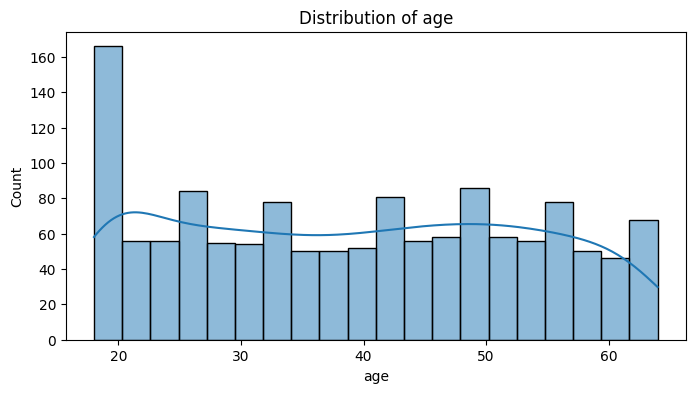

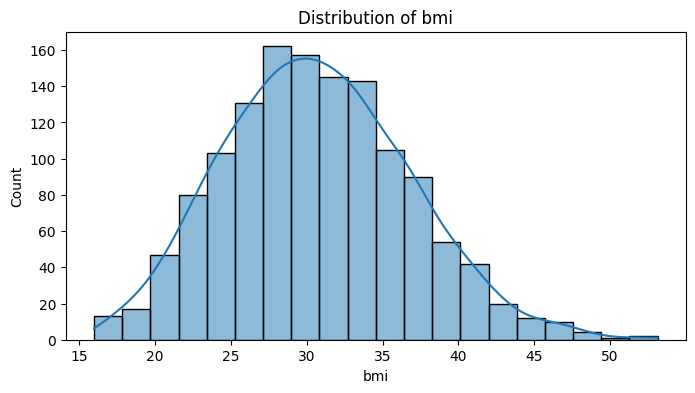

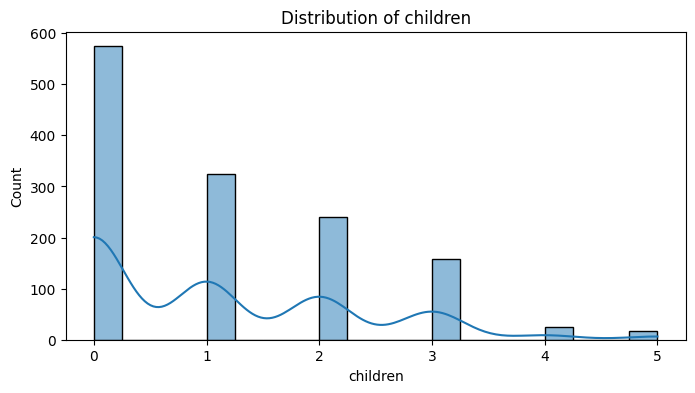

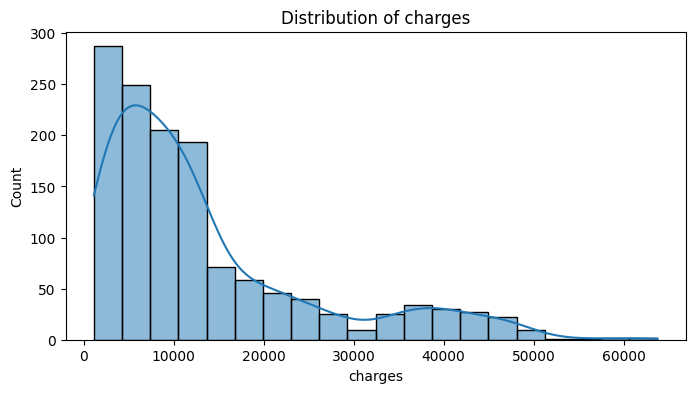

In [8]:
import seaborn as sns
numeric_columns = ['age', 'bmi', 'children', 'charges']

for i in numeric_columns:
    plt.figure(figsize=(8, 4)) 
    sns.histplot(data[i], kde=True, bins=20)
    plt.title(f'Distribution of {i}') 

<Axes: xlabel='children', ylabel='count'>

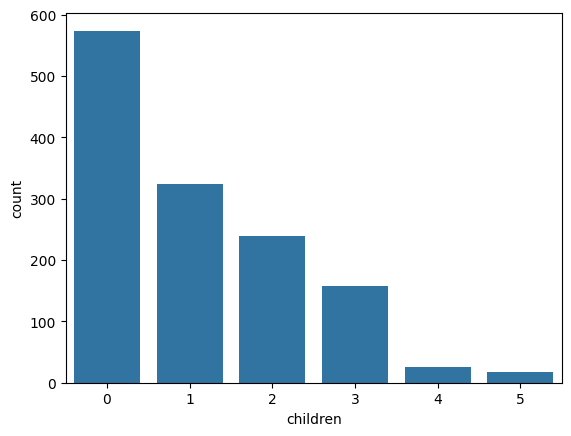

In [9]:
sns.countplot(x=data['children'])

<Axes: xlabel='smoker', ylabel='count'>

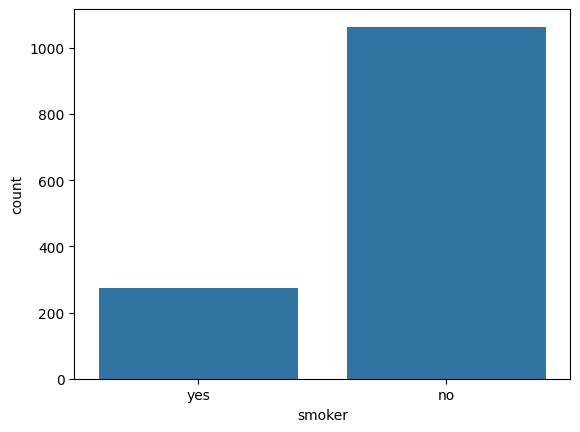

In [10]:
sns.countplot(x=data['smoker'])

<Axes: xlabel='sex', ylabel='count'>

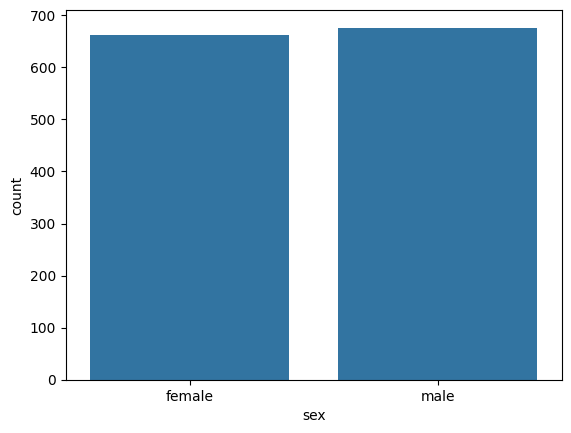

In [11]:
sns.countplot(x=data['sex'])

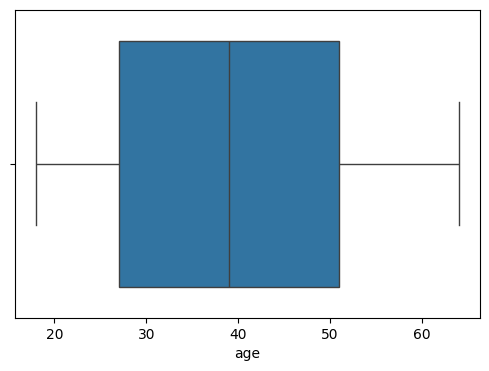

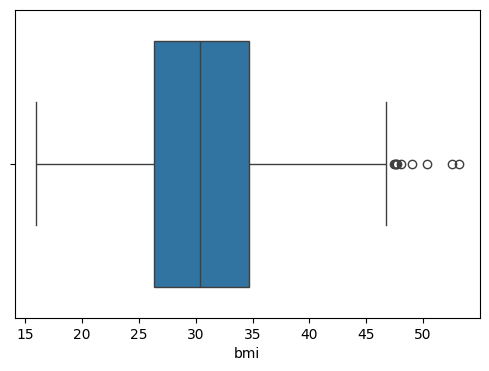

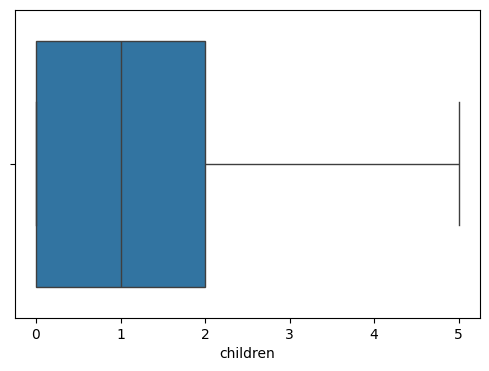

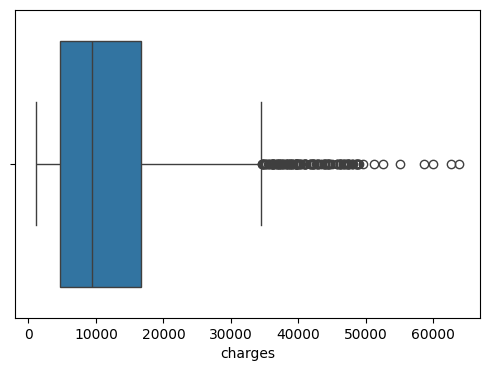

In [12]:
for i in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x= data[i])

<Axes: >

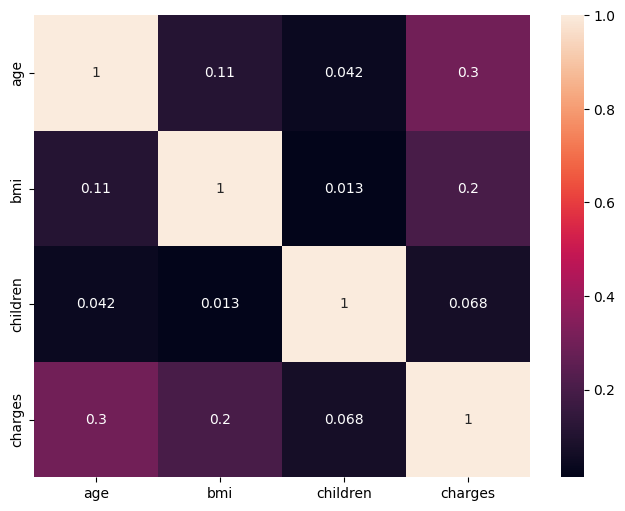

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True)

Data Cleaning and Preprocessing


In [14]:
data_cleaned=data.copy()

In [15]:
data_cleaned.shape

(1338, 7)

In [16]:
data_cleaned.drop_duplicates(inplace=True)

In [17]:
data_cleaned.shape

(1337, 7)

In [18]:
data_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
data_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [20]:
data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [21]:
data_cleaned['sex']=data_cleaned['sex'].map({'male': 0, 'female': 1})
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [22]:
data_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [23]:
data_cleaned['smoker']=data_cleaned['smoker'].map({'no': 0, 'yes': 1})
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [24]:
data_cleaned.rename(columns={'sex': 'isfemale',
                              'smoker': 'issmoker'}, inplace=True)
data_cleaned.head()

,age,isfemale,bmi,children,issmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [25]:
data_cleaned=pd.get_dummies(data_cleaned, columns=['region'], drop_first=True)


In [26]:
data_cleaned.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [27]:
data_cleaned=data_cleaned.astype(int)

In [28]:
data_cleaned.head(  )

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


Feature Extraction & Scaling


In [29]:
data_cleaned['bmi_category']=pd.cut(
    data_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['underweight', 'normal', 'overweight', 'obese']
)

In [30]:
data_cleaned.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight


In [31]:
data_cleaned=pd.get_dummies(data_cleaned, columns=['bmi_category'], drop_first=True)

In [32]:
data_cleaned.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [33]:
data_cleaned=data_cleaned.astype(int)

In [34]:
data_cleaned.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
cols=['age', 'bmi', 'children']
data_cleaned[cols]=scaler.fit_transform(data_cleaned[cols])
data_cleaned.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [36]:

data_cleaned["smoker_age"]   =data_cleaned["issmoker"] * data_cleaned["age"]
data_cleaned["smoker_bmi"]   = data_cleaned["issmoker"] * data_cleaned["bmi"]
data_cleaned["age_bmi"]      = data_cleaned["age"] * data_cleaned["bmi"]

# Polynomial features
data_cleaned["age_sq"]       = data_cleaned["age"] ** 2
data_cleaned["bmi_sq"]       = data_cleaned["bmi"] ** 2

# BMI-based risk flags
data_cleaned["bmi_obese"]    = (data_cleaned["bmi"] >= 30).astype(int)
data_cleaned["smoker_obese"] = data_cleaned["issmoker"] * data_cleaned["bmi_obese"]

# Log-transform target
data_cleaned["log_charges"]  = np.log1p(data_cleaned["charges"])

print("New features:")
print([c for c in data_cleaned.columns if c not in data.columns])

New features:
['isfemale', 'issmoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese', 'smoker_age', 'smoker_bmi', 'age_bmi', 'age_sq', 'bmi_sq', 'bmi_obese', 'smoker_obese', 'log_charges']


In [37]:
data_cleaned.columns

Index(['age', 'isfemale', 'bmi', 'children', 'issmoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese',
       'smoker_age', 'smoker_bmi', 'age_bmi', 'age_sq', 'bmi_sq', 'bmi_obese',
       'smoker_obese', 'log_charges'],
      dtype='object')

In [49]:
import scipy.stats

selected_features = ['isfemale', 'issmoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese', 'smoker_age', 'smoker_bmi', 'age_bmi', 'age_sq', 'bmi_sq', 'bmi_obese', 'smoker_obese', 'log_charges']

correlations = {
    feature: scipy.stats.pearsonr(data_cleaned[feature], data_cleaned['charges'])[0]
    for feature in selected_features
}
correlations_df=pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
print(correlations_df)

                    Feature  Pearson Correlation
0                  isfemale            -0.058046
1                  issmoker             0.787234
2          region_northwest            -0.038695
3          region_southeast             0.073577
4          region_southwest            -0.043637
5       bmi_category_normal            -0.104042
6   bmi_category_overweight            -0.120601
7        bmi_category_obese             0.200348
8                smoker_age             0.122772
9                smoker_bmi             0.349183
10                  age_bmi            -0.017186
11                   age_sq             0.053731
12                   bmi_sq             0.009952
13                bmi_obese                  NaN
14             smoker_obese                  NaN
15              log_charges             0.893099


In [50]:
from scipy.stats import chi2_contingency
import pandas as pd

cat_features=['isfemale', 'issmoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese', 'smoker_age', 'smoker_bmi', 'age_bmi', 'age_sq', 'bmi_sq', 'bmi_obese', 'smoker_obese', 'log_charges']

alpha = 0.05

data_cleaned['charges_bin'] = pd.qcut(data_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(data_cleaned[col], data_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
age_sq,1509.13025,0.0,Reject Null (Keep Feature)
issmoker,848.219178,0.0,Reject Null (Keep Feature)
smoker_bmi,911.635397,0.0,Reject Null (Keep Feature)
smoker_age,888.392616,0.0,Reject Null (Keep Feature)
age_bmi,2908.200798,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
isfemale,10.258784,0.01649,Reject Null (Keep Feature)
bmi_sq,144.758888,0.017278,Reject Null (Keep Feature)
log_charges,4011.0,0.033723,Reject Null (Keep Feature)
bmi_category_obese,8.515711,0.036473,Reject Null (Keep Feature)


In [56]:
data_final=data_cleaned[['charges', 'isfemale', 'issmoker', 'region_southeast', 'bmi_category_obese', 'smoker_age', 'smoker_bmi', 'age_bmi', 'age_sq', 'bmi_sq', 'log_charges']]

In [57]:
data_final.head()

,charges,isfemale,issmoker,region_southeast,bmi_category_obese,smoker_age,smoker_bmi,age_bmi,age_sq,bmi_sq,log_charges
0,16884,1,1,0,0,-1.440418,-0.517949,0.746063,2.074803,0.268271,9.734181
1,1725,0,0,1,1,-0.000000,0.000000,-0.699082,2.285078,0.213872,7.453562
2,4449,0,0,1,1,-0.000000,0.000000,-0.369670,0.638961,0.213872,8.400659
3,21984,0,0,0,0,-0.000000,-0.000000,0.591656,0.196427,1.782117,9.998116
4,3866,0,0,0,0,-0.000000,-0.000000,0.182390,0.264639,0.125704,8.260234


In [58]:
from sklearn.model_selection import train_test_split

In [60]:
X = data_final.drop('charges', axis=1)                
y = data_final['charges']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [64]:
from sklearn.metrics import r2_score

y_pred=model.predict(X_test)

r2=r2_score(y_test, y_pred)
r2


0.9448255333546122

In [65]:
n=X_test.shape[0]
p=X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2

0.9435453833164361